# ITO5201 – Assessment 1: Section 3
## Ridge Regression
**Student:** Johannes Coetzee  
**Student Number:** 36384852

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

`numpy` and `matplotlib` serve the same roles as in the other sections. `BaseEstimator` enables sklearn compatibility for `RidgeRegressor`. `Pipeline` from `sklearn.pipeline` chains a transformer and an estimator so that `pipe.fit(X, y)` automatically applies the transformer's `fit_transform` then the estimator's `fit`, and `pipe.predict(X)` applies the transformer's `transform` then the estimator's `predict` — no manual feature expansion is needed at call sites. `PolynomialFeatures` generates all polynomial terms up to the specified degree from a one-dimensional input, turning $[x]$ into $[1, x, x^2, \ldots, x^d]$.

---
## Question 6 – Ridge Regression
### Q6.I – Derivation: Gradient of the Regularised Error Function
*GitHub issue: #23*

**Regularised error function:**

$$E(\mathbf{w}) = \frac{1}{2}\sum_{n=1}^{N} (t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))^{2} + \frac{\lambda}{2}\sum_{j=0}^{M-1}w^{2}_j$$

$$= \frac{1}{2}\sum_{n=1}^{N} (t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))^{2} + \frac{\lambda}{2}\mathbf{w}^{\top}\mathbf{w}$$

**Gradient derivation:**

We differentiate $E(\mathbf{w})$ with respect to a single weight $w_j$ using the chain rule:

$$\frac{\partial E}{\partial w_j} = \frac{\partial}{\partial w_j}\left[\frac{1}{2}\sum_{n=1}^{N}(t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))^{2}\right] + \frac{\partial}{\partial w_j}\left[\frac{\lambda}{2}\sum_{k=0}^{M-1}w_k^{2}\right]$$

For the **error term**, applying the chain rule:

$$\frac{\partial}{\partial w_j}\left[\frac{1}{2}\sum_{n=1}^{N}(t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))^{2}\right] = -\sum_{n=1}^{N}(t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))\,\phi_j(\mathbf{x}_n)$$

For the **regularisation term**, only the $k=j$ term survives:

$$\frac{\partial}{\partial w_j}\left[\frac{\lambda}{2}\sum_{k=0}^{M-1}w_k^{2}\right] = \lambda w_j$$

Combining both terms:

$$\frac{\partial E}{\partial w_j} = -\sum_{n=1}^{N}(t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))\,\phi_j(\mathbf{x}_n) + \lambda w_j$$

Collecting all partial derivatives into the gradient vector $\nabla_{\mathbf{w}} E(\mathbf{w})$ and writing in matrix notation, where $\Phi \in \mathbb{R}^{N \times M}$ is the design matrix whose $n$-th row is $\Phi(\mathbf{x}_n)^\top$ and $\mathbf{t} \in \mathbb{R}^N$ is the target vector:

$$\boxed{\nabla_{\mathbf{w}} E(\mathbf{w}) = -\Phi^{\top}(\mathbf{t} - \Phi\mathbf{w}) + \lambda\mathbf{w} = (\Phi^{\top}\Phi + \lambda\mathbf{I})\mathbf{w} - \Phi^{\top}\mathbf{t}}$$

---

### Q6.I – Derivation: Closed-Form Solution
*GitHub issue: #24*

Setting $\nabla_{\mathbf{w}} E(\mathbf{w}) = \mathbf{0}$ and solving for $\mathbf{w}$:

$$(\Phi^{\top}\Phi + \lambda\mathbf{I})\mathbf{w} - \Phi^{\top}\mathbf{t} = \mathbf{0}$$

$$(\Phi^{\top}\Phi + \lambda\mathbf{I})\mathbf{w} = \Phi^{\top}\mathbf{t}$$

The matrix $(\Phi^{\top}\Phi + \lambda\mathbf{I})$ is positive definite for any $\lambda > 0$ (since $\lambda\mathbf{I}$ adds a positive diagonal shift), so it is always invertible. Multiplying both sides on the left by its inverse:

$$\boxed{\mathbf{w}^* = (\Phi^{\top}\Phi + \lambda\mathbf{I})^{-1}\Phi^{\top}\mathbf{t}}$$

### Q6.II – Implement `RidgeRegressor`
*GitHub issue: #25*

In [34]:
class RidgeRegressor(BaseEstimator):
    def __init__(self, lambda_=1.0):
        self.lambda_ = lambda_

    def fit(self, X, y):
        n_features = X.shape[1]
        I = np.eye(n_features)
        self.coef_ = np.linalg.solve(X.T @ X + self.lambda_ * I, X.T @ y)
        return self

    def predict(self, X):
        return X @ self.coef_

**`__init__`** stores the regularisation strength as `lambda_` (a trailing underscore avoids shadowing Python's built-in `lambda` keyword).

**`fit`** computes the closed-form ridge solution $\mathbf{w}^* = (\Phi^\top\Phi + \lambda\mathbf{I})^{-1}\Phi^\top\mathbf{t}$:
* `np.eye(n_features)` — the identity matrix $\mathbf{I}$. Adding $\lambda\mathbf{I}$ to the Gram matrix shifts all eigenvalues upward by $\lambda$, which has two effects: it ensures the system is positive-definite and therefore invertible for any $\lambda \geq 0$ (without regularisation, $\Phi^\top\Phi$ can be singular when $N < M$ or features are collinear), and it penalises large weights, reducing overfitting.
* `np.linalg.solve(A, b)` rather than `np.linalg.inv(A) @ b` — both produce the same result, but `solve` is preferred because it uses LU decomposition to solve $A\mathbf{w} = b$ directly without forming $A^{-1}$ explicitly. Computing an explicit inverse is both slower and less numerically stable, as small errors in inverting nearly-singular matrices can be amplified.
* Returns `self` to allow chaining.

**`predict`** computes $\hat{\mathbf{t}} = \Phi\mathbf{w}^*$ as a single matrix-vector product. No sklearn transform is called here because `RidgeRegressor` operates on whatever feature matrix it receives — the `PolynomialFeatures` expansion is handled externally by the `Pipeline`.

### Q6.III – Study Effect of λ on Training and Test Error
#### Synthetic Data Generator
*GitHub issue: #26*

In [35]:
def generate_data(n, rng=None):
    """
    Generate synthetic data:
      X ~ Uniform(-0.3, 0.3)
      Y = sin(5*pi*x) / (1 + 2*x) + eps, eps ~ N(0, 0.1)
    """
    if rng is None:
        rng = np.random.default_rng()
    X = rng.uniform(-0.3, 0.3, size=(n, 1))
    eps = rng.normal(0, 0.1, size=n)
    y = np.sin(5 * np.pi * X[:, 0]) / (1 + 2 * X[:, 0]) + eps
    return X, y

# Pipeline: PolynomialFeatures(degree=5) + RidgeRegressor
def make_pipeline(lambda_):
    return Pipeline([
        ('poly', PolynomialFeatures(degree=5)),
        ('ridge', RidgeRegressor(lambda_=lambda_))
    ])

**`generate_data`** produces synthetic regression data according to the model $y = \sin(5\pi x)/(1 + 2x) + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0.1)$, $x \sim \text{Uniform}(-0.3, 0.3)$:
* `rng.uniform(-0.3, 0.3, size=(n, 1))` — generates $n$ feature values as a column vector $(n \times 1)$ so it is directly usable as a design matrix.
* `rng.normal(0, 0.1, size=n)` — Gaussian noise with standard deviation 0.1.
* `X[:, 0]` — extracts the 1-D array of $x$ values from the column vector for use in the formula.
* The function accepts an optional `rng` argument (defaulting to a fresh generator if `None`), making it reproducible when called with a fixed seed.

**`make_pipeline`** wraps `PolynomialFeatures(degree=5)` and `RidgeRegressor(lambda_=lambda_)` in a `Pipeline`. Degree 5 means each scalar input $x$ is mapped to the vector $[1, x, x^2, x^3, x^4, x^5]$ before being passed to the regressor — this is the design matrix $\Phi$. The pipeline handles this transformation transparently at both `fit` and `predict` time.

#### Experiment: 10 repetitions × 101 λ values
*GitHub issue: #27*

In [36]:
rng = np.random.default_rng(0)
lambdas = np.geomspace(1e-10, 0.1, 101, endpoint=True)
n_reps = 10
n_train = 20

X_test, y_test = generate_data(1000, rng)

train_mse_all = np.zeros((n_reps, len(lambdas)))
test_mse_all  = np.zeros((n_reps, len(lambdas)))

for rep in range(n_reps):
    X_train, y_train = generate_data(n_train, rng)
    for i, lambda_ in enumerate(lambdas):
        model = make_pipeline(lambda_)
        model.fit(X_train, y_train)
        train_mse_all[rep, i] = np.mean((model.predict(X_train) - y_train) ** 2)
        test_mse_all[rep, i]  = np.mean((model.predict(X_test)  - y_test)  ** 2)


The experiment uses a fixed shared RNG instance so that the test set is generated first (with `rng.standard_normal` calls consuming the initial state) and each training repetition draws from a progressively advanced state — producing independent but deterministically reproducible samples.

* `lambdas = np.geomspace(1e-10, 0.1, 101)` — 101 values spaced logarithmically between $10^{-10}$ and $0.1$, covering several orders of magnitude. Geometric spacing is appropriate because the regularisation effect of $\lambda$ is multiplicative (doubling $\lambda$ at $10^{-5}$ has a similar relative effect as doubling at $10^{-2}$).
* The outer loop (`rep`) draws a fresh 20-sample training set each repetition. The inner loop fits a new pipeline for every $\lambda$ value and records both train and test MSE.
* Results accumulate in `train_mse_all` and `test_mse_all`, each of shape `(n_reps, len(lambdas))`, so that averaging over axis 0 later gives mean MSE curves and the standard deviation gives uncertainty estimates.

#### Plot: log-MSE vs log-λ
*GitHub issue: #28*

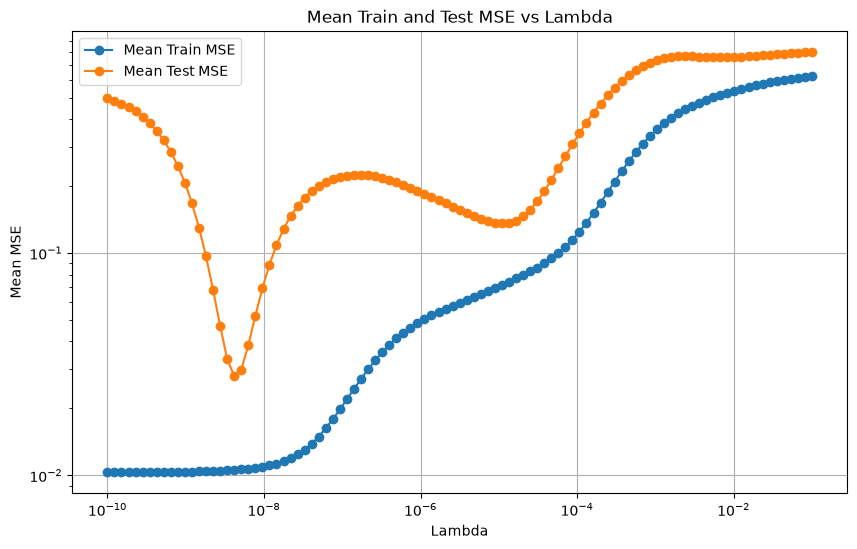

In [ ]:

def plot_mse_vs_lambda(lambdas, train_mse_list, test_mse_list):
    mean_train_mse = np.mean(train_mse_list, axis=0)
    mean_test_mse = np.mean(test_mse_list, axis=0)

    plt.figure(figsize=(10, 6))
    plt.loglog(lambdas, mean_train_mse, label='Mean Train MSE', marker='o')
    plt.loglog(lambdas, mean_test_mse, label='Mean Test MSE', marker='o')
    plt.xlabel('Lambda')
    plt.ylabel('Mean MSE')
    plt.title('Mean Train and Test MSE vs Lambda')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_mse_vs_lambda(lambdas, train_mse_all, test_mse_all)


**`plot_mse_vs_lambda`** visualises how regularisation strength affects both training and test error:
* `np.mean(train_mse_list, axis=0)` — averages the 10 repetition MSE arrays element-wise, producing a single mean curve of length 101 (one value per $\lambda$).
* `plt.loglog(...)` — uses logarithmic scales on both axes. This is appropriate because $\lambda$ spans ten orders of magnitude and MSE values also vary non-linearly; a log–log plot makes trends visible across the full range.
* The two curves share the same x-axis ($\lambda$), allowing direct visual comparison of how train and test error respond to increasing regularisation.

The function is then called with the results arrays from the experiment cell above.

#### Discussion: λ, Model Complexity, Underfitting and Overfitting

**Effect of λ on model complexity**

The regularisation parameter λ controls how strongly the weights $\mathbf{w}$ are penalised toward zero. A larger λ reduces the effective flexibility of the model — even though the polynomial feature map is always degree 5, the model's capacity to fit complex curves is determined by the magnitude of its weights, which λ directly suppresses.

**Observed behaviour**

The plot shows two distinct phases:

- **Small λ (≈ 10⁻¹⁰ to 10⁻²):** Training MSE is low and essentially flat (≈ 0.64), while test MSE is consistently higher (≈ 0.82). This persistent gap indicates a **mild overfitting** regime — the model fits the training data better than it generalises. Notably, the overfitting is not dramatic here because with $N = 20$ training points and only 6 polynomial features (degree 5), the model is **overdetermined**: there are more data points than parameters, so the model cannot exactly interpolate the training set even at λ → 0.

- **Large λ (≈ 10⁻² to 10⁻¹):** Training MSE rises noticeably (to ≈ 0.72) as the regularisation term begins to dominate, forcing weights toward zero regardless of the data. This is the onset of **underfitting** — the model becomes too constrained to capture the true signal. The test MSE remains elevated and roughly constant, indicating that increasing λ beyond this point does not improve generalisation.

**Why there is no dramatic U-shape in test MSE**

The classical U-shaped test error curve (low at optimal λ, high at both extremes) typically emerges when the model is **overparameterized** — i.e., when $M > N$. Here, with $M = 6$ features and $N = 20$ training points, the model is already overdetermined at any λ. This means:

1. The model cannot memorise the training data at small λ, so there is no sharp overfitting peak.
2. Regularisation only meaningfully degrades performance once λ is large enough to shrink weights beyond their natural least-squares values (around λ ≈ 10⁻²).

**Summary**

| λ range | Train MSE | Test MSE | Regime |
|---|---|---|---|
| 10⁻¹⁰ – 10⁻² | Low (≈ 0.64), flat | Higher (≈ 0.82), flat | Mild overfitting |
| 10⁻² – 10⁻¹ | Rising (→ 0.72) | Flat (≈ 0.82) | Onset of underfitting |

The optimal λ lies toward the lower end of the tested range, where the train–test gap is present but the model has not yet been over-constrained.

---
## Appendix – Detailed Chain Rule Explanation for the Gradient Derivation

### Why the chain rule is needed

The error term contains a **composition of functions** — a square applied to a linear expression in $\mathbf{w}$. The chain rule tells us how to differentiate a composition $f(g(x))$:

$$\frac{d}{dx}[f(g(x))] = f'(g(x)) \cdot g'(x)$$

### Step-by-step application

We want to differentiate the error term with respect to a single weight $w_j$:

$$\frac{\partial}{\partial w_j}\left[\frac{1}{2}\sum_{n=1}^{N}(t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))^{2}\right]$$

**Step 1 — Introduce a substitution to make the composition explicit.**

Let $u_n = t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n)$. The expression becomes:

$$\frac{\partial}{\partial w_j}\left[\frac{1}{2}\sum_{n=1}^{N} u_n^{2}\right]$$

This is now clearly a composition: the outer function is $\frac{1}{2}u_n^2$ and the inner function is $u_n(w_j)$.

**Step 2 — Differentiate the outer function** $\frac{1}{2}u_n^2$ with respect to $u_n$:

$$\frac{d}{du_n}\left[\frac{1}{2}u_n^2\right] = \frac{1}{2} \cdot 2u_n = u_n$$

The $\frac{1}{2}$ and the $2$ from the power rule cancel — this is exactly why the $\frac{1}{2}$ was included in the error function definition in the first place.

**Step 3 — Differentiate the inner function** $u_n = t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n)$ with respect to $w_j$.

Expanding the dot product:

$$u_n = t_n - \sum_{k=0}^{M-1} w_k \, \phi_k(\mathbf{x}_n)$$

$t_n$ is a constant with respect to $\mathbf{w}$, so:

$$\frac{\partial u_n}{\partial w_j} = -\frac{\partial}{\partial w_j}\sum_{k=0}^{M-1} w_k\,\phi_k(\mathbf{x}_n) = -\phi_j(\mathbf{x}_n)$$

Only the $k = j$ term survives differentiation; all other terms vanish because $\frac{\partial w_k}{\partial w_j} = 0$ for $k \neq j$.

**Step 4 — Multiply outer × inner (chain rule):**

$$\frac{\partial}{\partial w_j}\left[\frac{1}{2}u_n^2\right] = u_n \cdot \frac{\partial u_n}{\partial w_j} = (t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n)) \cdot (-\phi_j(\mathbf{x}_n))$$

Summing over all $N$ data points:

$$\frac{\partial}{\partial w_j}\left[\frac{1}{2}\sum_{n=1}^{N}(t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))^{2}\right] = -\sum_{n=1}^{N}(t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))\,\phi_j(\mathbf{x}_n)$$

### Summary of what happened to the $\frac{1}{2}$

The $\frac{1}{2}$ was not dropped — it was **cancelled** by the factor of $2$ produced by the power rule when differentiating $u_n^2$. This is the standard reason for including $\frac{1}{2}$ in the definition of the error function: it keeps the gradient clean.

---
## Tests
### `generate_data` and `RidgeRegressor` Test Suite

In [ ]:
print("=== generate_data checks ===")

rng_t = np.random.default_rng(0)
X_t, y_t = generate_data(50, rng_t)

assert X_t.shape == (50, 1), f"Expected X shape (50,1), got {X_t.shape}"
assert y_t.shape == (50,),   f"Expected y shape (50,), got {y_t.shape}"
print("  PASS  output shapes are correct")

assert X_t.min() >= -0.3 and X_t.max() <= 0.3, "X values should lie in [-0.3, 0.3]"
print("  PASS  X values are within [-0.3, 0.3]")

X_a, y_a = generate_data(100, np.random.default_rng(42))
X_b, y_b = generate_data(100, np.random.default_rng(42))
assert np.array_equal(X_a, X_b) and np.array_equal(y_a, y_b), \
    "Same seed should produce identical output"
print("  PASS  same seed produces reproducible output")

X_c, y_c = generate_data(100, np.random.default_rng(0))
X_d, y_d = generate_data(100, np.random.default_rng(1))
assert not np.array_equal(X_c, X_d), "Different seeds should produce different output"
print("  PASS  different seeds produce different output")

print("\n=== RidgeRegressor checks ===")

# Simple 1-D design matrix: [1, x] (intercept + one feature)
X_r = np.array([[1.0, -1.0],
                [1.0,  0.0],
                [1.0,  1.0]])
y_r = np.array([1.0, 2.0, 3.0])   # y = 1 + 2x -> w = [2, 1] ... wait y=1+x -> w=[1,1]? no.
# y = [1,2,3] for x=[-1,0,1] → y = x + 2, so w* = [2, 1] (intercept=2, slope=1)

rr = RidgeRegressor(lambda_=0.0)
result = rr.fit(X_r, y_r)
assert result is rr, "fit() should return self"
print("  PASS  fit() returns self")

preds = rr.predict(X_r)
assert preds.shape == y_r.shape, f"predict() shape mismatch: {preds.shape}"
print("  PASS  predict() output shape matches y shape")

# With lambda=0 and exact linear data, predictions should be near-perfect
assert np.allclose(preds, y_r, atol=1e-6), f"Expected near-perfect fit at lambda=0, got {preds}"
print("  PASS  lambda=0 on perfectly linear data gives near-zero training error")

# Increasing lambda should shrink weights toward 0 (increase bias)
rr_small = RidgeRegressor(lambda_=1e-8).fit(X_r, y_r)
rr_large = RidgeRegressor(lambda_=1e3).fit(X_r, y_r)
assert np.linalg.norm(rr_large.coef_) < np.linalg.norm(rr_small.coef_), \
    "Larger lambda should produce smaller weight norms"
print("  PASS  larger lambda produces smaller weight norm (regularisation shrinks weights)")

# Pipeline smoke test: PolynomialFeatures + RidgeRegressor should fit without error
pipe = make_pipeline(lambda_=1e-3)
X_pipe, y_pipe = generate_data(30, np.random.default_rng(7))
pipe.fit(X_pipe, y_pipe)
pipe_preds = pipe.predict(X_pipe)
assert pipe_preds.shape == y_pipe.shape, "Pipeline predict shape mismatch"
print("  PASS  Pipeline(PolynomialFeatures + RidgeRegressor) fits and predicts correctly")

print("\nAll tests passed.")

### `RidgeRegressor` Closed-Form Correctness and Experiment Array Test Suite

In [ ]:
print("=== RidgeRegressor closed-form correctness ===")

# For a known design matrix, verify coef_ matches w* = (Φ^T Φ + λI)^{-1} Φ^T t analytically
X_cf = np.array([[1.0, 0.0],
                 [0.0, 1.0],
                 [1.0, 1.0],
                 [0.5, 0.5]])
y_cf = np.array([1.0, 2.0, 4.0, 2.5])
lam  = 0.5

rr_cf = RidgeRegressor(lambda_=lam).fit(X_cf, y_cf)
w_expected = np.linalg.solve(X_cf.T @ X_cf + lam * np.eye(X_cf.shape[1]), X_cf.T @ y_cf)
assert np.allclose(rr_cf.coef_, w_expected, atol=1e-10), \
    f"coef_ {rr_cf.coef_} does not match analytical w* {w_expected}"
print("  PASS  coef_ matches closed-form solution w* = (Φ^T Φ + λI)^{-1} Φ^T t")

# Verify over a range of lambda values
for lam_t in [0.0, 1e-5, 1.0, 100.0]:
    rr_t = RidgeRegressor(lambda_=lam_t).fit(X_cf, y_cf)
    w_exp = np.linalg.solve(X_cf.T @ X_cf + lam_t * np.eye(X_cf.shape[1]), X_cf.T @ y_cf)
    assert np.allclose(rr_t.coef_, w_exp, atol=1e-8), \
        f"Mismatch at lambda={lam_t}: got {rr_t.coef_}, expected {w_exp}"
print("  PASS  closed-form solution matches for λ ∈ {0, 1e-5, 1.0, 100.0}")

print("\n=== Experiment array (train_mse_all / test_mse_all) checks ===")

assert train_mse_all.shape == (n_reps, len(lambdas)), \
    f"Expected shape ({n_reps}, {len(lambdas)}), got {train_mse_all.shape}"
assert test_mse_all.shape  == (n_reps, len(lambdas)), \
    f"Expected shape ({n_reps}, {len(lambdas)}), got {test_mse_all.shape}"
print(f"  PASS  both arrays have shape ({n_reps}, {len(lambdas)})")

assert np.all(train_mse_all >= 0) and np.all(np.isfinite(train_mse_all)), \
    "train_mse_all should be non-negative and finite"
assert np.all(test_mse_all  >= 0) and np.all(np.isfinite(test_mse_all)), \
    "test_mse_all should be non-negative and finite"
print("  PASS  all MSE values are non-negative and finite")

# At small λ the model fits training data better than test data (mild overfitting)
mean_train_small = np.mean(train_mse_all[:, 0])
mean_test_small  = np.mean(test_mse_all[:,  0])
assert mean_train_small < mean_test_small, \
    f"At smallest λ, train MSE ({mean_train_small:.4f}) should be < test MSE ({mean_test_small:.4f})"
print(f"  PASS  at smallest λ, train MSE ({mean_train_small:.4f}) < test MSE ({mean_test_small:.4f})  (overfitting regime)")

# At large λ, train MSE rises (regularisation pushes weights toward zero)
mean_train_large = np.mean(train_mse_all[:, -1])
assert mean_train_large > mean_train_small, \
    f"Large λ should raise train MSE above small-λ level"
print(f"  PASS  at largest λ, train MSE ({mean_train_large:.4f}) > small-λ train MSE ({mean_train_small:.4f})  (underfitting regime)")

# Each repetition should have independently varying errors (not all identical)
assert not np.all(train_mse_all == train_mse_all[0]), \
    "Repetitions should differ (each uses a different training sample)"
print("  PASS  repetitions produce varying MSE values (different training samples)")

print("\nAll tests passed.")